<a href="https://colab.research.google.com/github/ZahraRasooli-200/MATLAB-practice/blob/main/dog_cat_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset , random_split
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

In [5]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

In [6]:
full_dataset = OxfordIIITPet(root='/data', split='trainval',transform=transform, download=True)

100%|██████████| 792M/792M [00:40<00:00, 19.6MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.13MB/s]


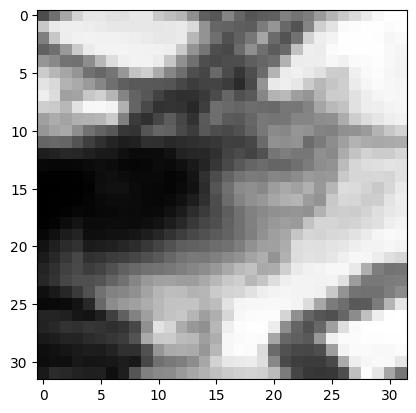

In [7]:
import matplotlib.pyplot as plt
plt.imshow(full_dataset[0][0].view(32,32), cmap='gray')


In [8]:
full_dataset[0]

(tensor([0.3294, 0.4588, 0.6627,  ..., 0.9059, 0.6627, 0.4824]), 0)

In [9]:
#full_dataset.classes
persian_class = full_dataset.classes.index('Persian')
shiba_inu_class = full_dataset.classes.index('Shiba Inu')

selected_indices = []
for idx, data in enumerate(full_dataset):
    if data[1] == persian_class:
        selected_indices.append(idx)
        full_dataset._labels[idx] = 0

    if data[1] == shiba_inu_class:
        selected_indices.append(idx)
        full_dataset._labels[idx] = 1

selected_dataset = Subset(full_dataset, selected_indices)
len(selected_dataset)

200

In [10]:
train_dataset ,val_dataset = random_split(selected_dataset, [0.9,0.1], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=20, shuffle=False)

In [21]:
class OneLayerNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(32*32,1))
  def forward(self,x):
    return self.net(x).squeeze(1)


class FourLayerNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(32*32,128),
    nn.ReLU(),
    nn.Linear(128,128),
    nn.ReLU(),
    nn.Linear(128,128),
    nn.ReLU(),
    nn.Linear(128,1)
    )
  def forward(self,x):
    return self.net(x).squeeze(1)

In [22]:
shallow_model = OneLayerNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(shallow_model.parameters(), lr=0.001)

In [24]:
epochs = 100
best_acc = 0
for epoch in range(epochs):
  shallow_model.train()
  train_loss = 0
  for images, targets in train_loader:
    optimizer.zero_grad()
    outputs = shallow_model(images)
    loss = criterion(outputs, targets.float())
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_loss = train_loss / len(train_loader)


#eval
shallow_model.eval()
with torch.no_grad():
  val_loss = 0
  corrects = 0
  total = 0
  for images, targets in val_loader:
    outputs = shallow_model(images)
    val_loss += criterion(outputs, targets.float()).item()
    predictions = (torch.sigmoid(outputs) > 0.5).float()
    corrects += (predictions == targets).sum().item()
    total += outputs.size(0)
  val_loss = val_loss / len(val_loader)
  val_acc = corrects / total

if val_acc > best_acc:
  best_acc = val_acc
  torch.save(shallow_model.state_dict(), 'best_shallow_model.pth')
  print(f'est model save with acc: {best_acc}')
print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

est model save with acc: 0.45
Epoch 99, Train Loss: 0.6567, Val Loss: 0.7131, Val Acc: 0.4500


In [25]:
deep_model = FourLayerNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(deep_model.parameters(), lr=0.001)

In [26]:
epochs = 100
best_acc = 0
for epoch in range(epochs):
  deep_model.train()
  train_loss = 0
  for images, targets in train_loader:
    optimizer.zero_grad()
    outputs = deep_model(images)
    loss = criterion(outputs, targets.float())
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_loss = train_loss / len(train_loader)


#eval
deep_model.eval()
with torch.no_grad():
  val_loss = 0
  corrects = 0
  total = 0
  for images, targets in val_loader:
    outputs = deep_model(images)
    val_loss += criterion(outputs, targets.float()).item()
    predictions = (torch.sigmoid(outputs) > 0.5).float()
    corrects += (predictions == targets).sum().item()
    total += outputs.size(0)
  val_loss = val_loss / len(val_loader)
  val_acc = corrects / total

if val_acc > best_acc:
  best_acc = val_acc
  torch.save(deep_model.state_dict(), 'best_shallow_model.pth')
  print(f'est model save with acc: {best_acc}')
print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

est model save with acc: 0.45
Epoch 99, Train Loss: 0.6919, Val Loss: 0.6952, Val Acc: 0.4500


In [32]:
def predict(input_image):
  model = FourLayerNN()
  model.load_state_dict(torch.load('best_shallow_model.pth'))
  outputs = model(input_image.unsqueeze(0))
  predictions =(torch.sigmoid(outputs) > 0.5).float()
  print(predictions)
  plt.figure(figsize=(2,2))
  plt.imshow(input_image.view(32,32), cmap='gray')

tensor([0.])


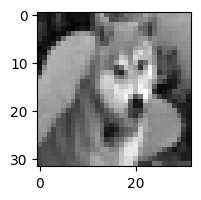

In [33]:
predict(val_dataset[0][0])